## Clusters

### Climate clusters

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, Model

import geopandas as gpd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [21]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

#### Data preprocessing

In [3]:
data = pd.read_csv('data/climate.csv')
cols = ['t_mean', 'rh_mean'] # Subset of variables
data['week_end'] = pd.to_datetime(data['week_end'])

In [4]:
data_list = []
geoids = []
for geoid, group in data.groupby('geoid'):
    data_list.append(group[cols].values)
    geoids.append(geoid)
X = np.array(data_list)

n_counties, n_weeks, n_features = X.shape
X_reshaped = X.reshape(-1, n_features)

scaler = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_reshaped)

X_train = X_scaled_flat.reshape(n_counties, n_weeks, n_features)
X_scaled = X_train.reshape(n_counties, -1)

print(f"Final shape for LSTM: {X_train.shape}") 

Final shape for LSTM: (3211, 157, 2)


#### Autoencoder

In [ ]:
# Configuración
latent_dim = 16
timesteps = X_train.shape[1]
features = X_train.shape[2]

# --- ENCODER ---
inputs = layers.Input(shape=(timesteps, features))
h = layers.LSTM(64, activation='tanh', return_sequences=True)(inputs)
latent_vector = layers.LSTM(latent_dim, activation='tanh', return_sequences=False)(h)

encoder_model = Model(inputs, latent_vector, name="Encoder")

# --- DECODER ---
decoder_input = layers.RepeatVector(timesteps)(latent_vector)
h_dec = layers.LSTM(64, activation='tanh', return_sequences=True)(decoder_input)
output = layers.TimeDistributed(layers.Dense(features))(h_dec)

# --- AUTOENCODER COMPLETO ---
autoencoder = Model(inputs, output, name="Autoencoder")
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='mse')

autoencoder.summary()

In [ ]:
# Entrenamiento
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.1)

# Generation of vectors for clustering
latent_features = encoder_model.predict(X_train)

In [ ]:
# Save encoder model
encoder_model.save("models/encoder_vanilla_16.keras")

In [16]:
# Load saved encoder
encoder = tf.keras.models.load_model("models/encoder_vanilla_16.keras")

# Generation of vectors for clustering
latent_features = encoder.predict(X_train)

101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


#### Clustering

In [6]:
# Kmeans clustering function
def kmeans_clustering(X, n_clusters=5):
    model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
    print(f"Silhouette score: {silhouette_score(X, model.labels_, metric="euclidean")}")
    return model.labels_

In [7]:
# USA map to color clusters

url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
usa = gpd.read_file(url)
usa['GEOID'] = usa['GEOID'].astype(str).str.zfill(5)

def eeuu_map(clusters, X_original, var=0, model_name=""):

    warnings.filterwarnings('ignore')

    mean_temp_county = X_original[:, :, var].mean(axis=1)
    
    df_temp = pd.DataFrame({
        'cluster_original': clusters,
        'mean_temp': mean_temp_county
    })
    
    cluster_stats = df_temp.groupby('cluster_original')['mean_temp'].mean().sort_values(ascending=False)
    
    reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
    new_clusters = np.array([reorder_map[label] for label in clusters])
    
    n_clusters = len(np.unique(new_clusters))
    df_clusters = pd.DataFrame({'GEOID': geoids, 'cluster_ordenado': new_clusters})
    df_clusters['GEOID'] = df_clusters['GEOID'].astype(str).str.zfill(5)

    map_df = usa.merge(df_clusters, on='GEOID')
    mainland = map_df[~map_df['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI'])]

    cmap_clima = plt.cm.get_cmap('RdYlBu')

    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    
    mainland.plot(column='cluster_ordenado', 
                  cmap=cmap_clima,
                  categorical=True,
                  legend=True,
                  ax=ax,
                  linewidth=0.1, 
                  edgecolor='white',
                  legend_kwds={'title': "Ranking Térmico\n(0=Más Cálido)", 
                               'loc': 'lower right',
                               'bbox_to_anchor': (1, 0)})

    ax.set_title(f'Mapa de Clusters Climáticos\n{model_name}, K={n_clusters}', fontsize=16)
    ax.axis('off')
    
    plt.show()

    reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
    labels_finales = np.array([reorder_map[l] for l in df_temp['cluster_original']])

    return labels_finales


Silhouette score: 0.331108033657074


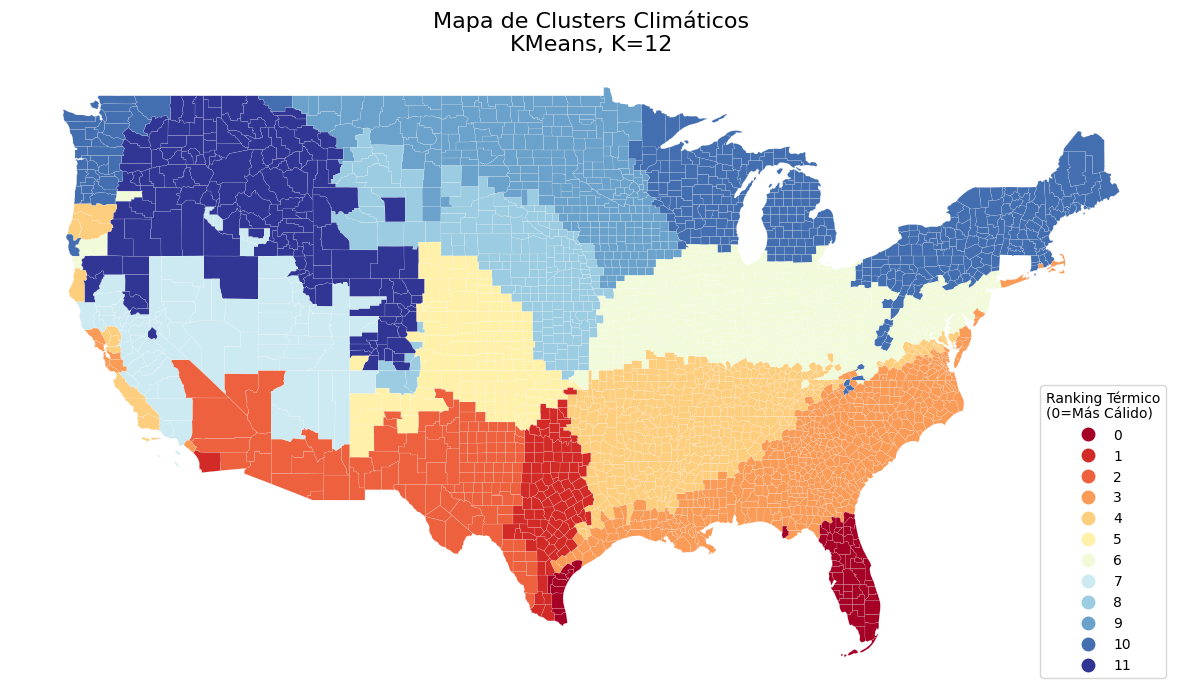

In [13]:
labs = kmeans_clustering(latent_features, n_clusters=12)
labs_reencoded = eeuu_map(labs, X, model_name='KMeans')

In [15]:
climate_mapping = {
    0: "Tropical Humid",
    1: "Warm Temperate / Subtropical Transition",
    2: "Arid Warm (Desert)",
    3: "Warm Temperate Humid (Deep South)",
    4: "Subtropical Humid Atlantic",
    5: "Semiarid Continental",
    6: "Temperate Continental Humid",
    7: "High Altitude Dry Continental",
    8: "Semiarid Cold",
    9: "Cold Continental / Great Lakes",
    10: "Cold Maritime / Pacific Northwest",
    11: "Subarctic Mountain"
}

df_final = pd.DataFrame({
    'geoid': geoids,
    'cluster': labs_reencoded
})

df_final['geoid'] = df_final['geoid'].astype(str).str.zfill(5)
df_final['climate_type'] = df_final['cluster'].map(climate_mapping)

df_final.to_csv('data/climate_clusters.csv', index=False)

### Sociodemographic clusters

In [17]:
df1 = pd.read_csv("data/quickfacts_allus.csv", encoding = "latin1")
df2 = pd.read_csv("data/disabilities_allcounties.csv", encoding = "latin1")

# merging both datasets
for df in [df1, df2]:
    df["county"] = df["county"].astype(str).str.strip().str.lower()
    df["state"] = df["state"].astype(str).str.strip().str.lower()

df2["disability_prevalence"] = df2["disability_prevalence"].astype(str).str.replace("%", "").astype(float)

df = pd.merge(
    df1,
    df2[["county", "state", "disability_prevalence"]],
    on=["county", "state"],
    how="left"
)

In [19]:
# Cleanning of data

# The quality of all the data belonging to Connecticut is not the best, as there are many missing values that cannot be imputated.
df = df[df["state"] != "connecticut"]

df = df.drop(columns= ["county", "state", "population_2024", "education_hsorhigher (25+)", "income_household (2024 dollars)", "age_under5"]) #removing irrelevant variables, and those that would result in high collineality
df = df.rename(columns={"education_bachelorsorhigher (25+)": "education_bachelorsorhigher", "income_percapita (2024 dollars)": "income_percapita", "population_density (square mile 2020)": "population_density"})

#these changes have to do with age variables
df = df.rename(columns={"age_under18": "youth_share", "age_65andover": "elderly_share"})
df["dependency_ratio"] = df["youth_share"] + df["elderly_share"]

#these have to do with racial/ethnic variables
df["minority_share"] = 100- df["race_white"]
df["hispanic_share"] = df["race_hispanicorlatino"]
df = df.drop(columns=["race_white", "race_black", "race_americanindianoralaskanative", "race_asian", "race_nativehawaiianorpacificislander","race_hispanicorlatino"])

#finally, dealing with some missing values.
df["disability_prevalence"] = df["disability_prevalence"].fillna(df["disability_prevalence"].median())
df["without_insuranceunder65"] = df["without_insuranceunder65"].fillna(df["without_insuranceunder65"].median())

#convert object to number
df["population_density"] = pd.to_numeric(
    df["population_density"],
    errors="coerce"
)

In [ ]:
log_vars = ["income_percapita", "population_density", "medianval_ownerunits"]

for col in log_vars:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=True)
        .replace("-", np.nan)
    )

#we want to make sure that all the columns are numeric
    df[col] = pd.to_numeric(df[col], errors="coerce")

#there were a few missing values, which will be replaced with the median
    df[col] = df[col].fillna(df[col].median())

# log tranformation to "balance" numeric values that are not percentages.
    df[col] = np.log1p(df[col])

In [22]:
#normalize data
scaler = MinMaxScaler()
df_final = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

#carry out PCA to reduce dimensionality
pca = PCA(n_components=5)
X_pca = pca.fit_transform(df_final)

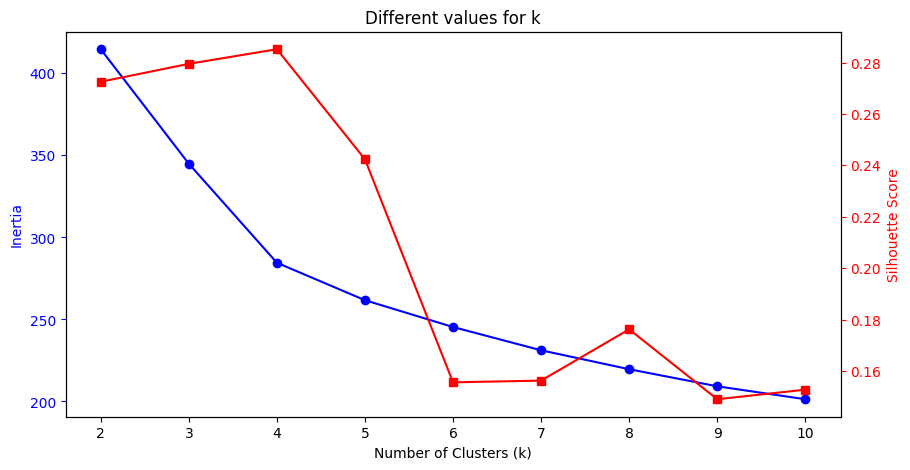

In [23]:
#Evaluating different values for k
inertia = []
silhouette_scores = []
range_diffk = range(2, 11)

for k in range_diffk:
    kmeans_test = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        max_iter=300,
        random_state=42
    )

    cluster_labels = kmeans_test.fit_predict(df_final)

    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(df_final, cluster_labels))

#Elbow graph
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje izquierdo: Inercia (Codo)
ax1.plot(range_diffk, inertia, 'bo-', label='Inercia (Codo)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params('y', colors='b')

# Eje derecho: Silhouette Score
ax2 = ax1.twinx()
ax2.plot(range_diffk, silhouette_scores, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

plt.title('Different values for k')
plt.show()

In [26]:
best_k = 4

kmeans_final = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42
)

df["cluster_kmeans"] = kmeans_final.fit_predict(df_final)